# Network Intrusion Detection System : XGBoost (GPU L4)
## Dataset: UNSW-NB15 | Multiclass Classification (attack_cat — 10 classes)

**Classes:** Normal, Fuzzers, Analysis, Backdoors, DoS, Exploits, Generic, Reconnaissance, Shellcode, Worms

**Pipeline:**
1. GPU Setup
2. Data Loading
3. Preprocessing : Drop / Clean / Variance / Correlation
4. Train / Validation / Test Split (70 / 10 / 20)
5. Target Encoding (leak-free, fit on train only)
6. Mutual Information Feature Selection (on train only)
7. Scaling + SMOTE
8. Focal Loss (custom objective)
9. XGBoost Training (GPU : device='cuda')
10. Hyperparameter Tuning (RandomizedSearchCV)
11. Evaluation : Confusion Matrix, FPR per class
12. Feature Importance
13. Results Summary

## 1. GPU Setup

In [1]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

import torch
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('No GPU detected. Set runtime to L4.')

Fri Mar 27 07:55:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   35C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q xgboost --upgrade
!pip install -q imbalanced-learn scikit-learn category_encoders pandas numpy matplotlib seaborn

import os
import glob
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import LabelEncoder, QuantileTransformer
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score,
    precision_score, recall_score
)
from category_encoders import TargetEncoder
from imblearn.over_sampling import SMOTE
from scipy.stats import randint, uniform

import joblib


warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print(f'XGBoost version: {xgb.__version__}')
print('Libraries loaded.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 8.5 MB/s eta 0:00:00
XGBoost version: 3.2.0
Libraries loaded.


## 2. Data Loading

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
# UNSW-NB15 is provided as pre-split train and test files.
# Update DATA_DIR to match your Google Drive path.
DATA_DIR = '/content/drive/MyDrive/Tez_kodu/UNSW-NB15/'  # update if needed

TRAIN_FILE = os.path.join(DATA_DIR, 'UNSW_NB15_training-set.csv')
TEST_FILE  = os.path.join(DATA_DIR, 'UNSW_NB15_testing-set.csv')

# Typo guard: also try the misspelled variant present in some distributions
if not os.path.exists(TRAIN_FILE):
    TRAIN_FILE = os.path.join(DATA_DIR, 'UNSW_NB15_traiing-set.csv')

print(f'Train file : {TRAIN_FILE}')
print(f'Test file  : {TEST_FILE}')
print(f'Train exists: {os.path.exists(TRAIN_FILE)}')
print(f'Test exists : {os.path.exists(TEST_FILE)}')

df_train = pd.read_csv(TRAIN_FILE, low_memory=False)
df_test  = pd.read_csv(TEST_FILE,  low_memory=False)

df_train.columns = df_train.columns.str.strip()
df_test.columns  = df_test.columns.str.strip()

# Concatenate into one dataframe — split will be redone properly in section 5
df = pd.concat([df_train, df_test], ignore_index=True)
print(f'\nTrain shape : {df_train.shape}')
print(f'Test shape  : {df_test.shape}')
print(f'Combined    : {df.shape}')
print(f'Columns     : {df.columns.tolist()}')

Train file : /content/drive/MyDrive/Tez_kodu/UNSW-NB15/UNSW_NB15_training-set.csv
Test file  : /content/drive/MyDrive/Tez_kodu/UNSW-NB15/UNSW_NB15_testing-set.csv
Train exists: True
Test exists : True

Train shape : (82332, 45)
Test shape  : (175341, 45)
Combined    : (257673, 45)
Columns     : ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [20]:
# UNSW-NB15: attack_cat has NaN for normal traffic
df['attack_cat'] = df['attack_cat'].fillna('Normal').str.strip()

print('attack_cat distribution:')
print(df['attack_cat'].value_counts())
print(f'Number of classes: {df["attack_cat"].nunique()}')
df.head()

attack_cat distribution:
attack_cat
Normal            93000
Generic           58871
Exploits          44525
Fuzzers           24246
DoS               16353
Reconnaissance    13987
Analysis           2677
Backdoor           2329
Shellcode          1511
Worms               174
Name: count, dtype: int64
Number of classes: 10


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


## 3. Preprocessing : Drop / Clean / Variance / Correlation

Number of classes: 10
Class mapping:
   0 -> Analysis             (2,677)
   1 -> Backdoor             (2,329)
   2 -> DoS                  (16,353)
   3 -> Exploits             (44,525)
   4 -> Fuzzers              (24,246)
   5 -> Generic              (58,871)
   6 -> Normal               (93,000)
   7 -> Reconnaissance       (13,987)
   8 -> Shellcode            (1,511)
   9 -> Worms                (174)


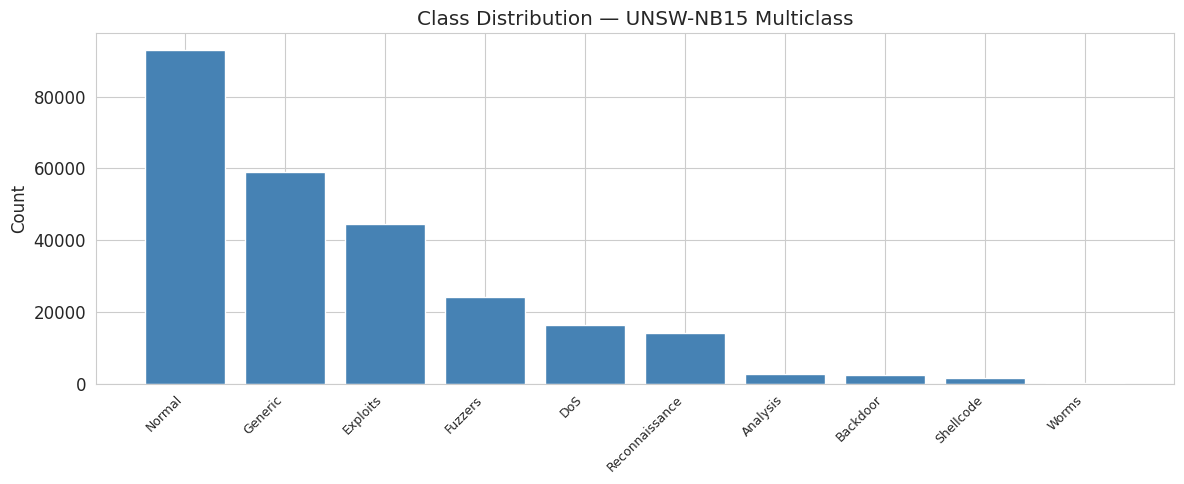

In [21]:
LABEL_COL = 'attack_cat'

le = LabelEncoder()
df['target'] = le.fit_transform(df[LABEL_COL])
y = df['target'].values
class_names = le.classes_
n_classes   = len(class_names)

print(f'Number of classes: {n_classes}')
print('Class mapping:')
for i, name in enumerate(class_names):
    print(f'  {i:2d} -> {name:<20} ({(y == i).sum():,})')

vc = df[LABEL_COL].value_counts()
plt.figure(figsize=(12, 5))
plt.bar(range(len(vc)), vc.values, color='steelblue')
plt.xticks(range(len(vc)), vc.index, rotation=45, ha='right', fontsize=9)
plt.ylabel('Count')
plt.title('Class Distribution — UNSW-NB15 Multiclass')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Drop identifier and label columns, keep X_raw with all features
DROP_COLS = [LABEL_COL, 'target', 'label', 'srcip', 'dstip', 'Stime', 'Ltime']
DROP_COLS = [c for c in DROP_COLS if c in df.columns]

X_raw    = df.drop(columns=DROP_COLS).copy()
cat_cols = X_raw.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()

print(f'Categorical columns : {cat_cols}')
print(f'Numerical columns   : {len(num_cols)}')
print(f'Total features      : {X_raw.shape[1]}')

Categorical columns : ['proto', 'service', 'state']
Numerical columns   : 40
Total features      : 43


In [23]:
# Handle Inf and NaN on numeric columns
X_raw[num_cols] = X_raw[num_cols].replace([np.inf, -np.inf], np.nan)
X_raw[num_cols] = X_raw[num_cols].fillna(X_raw[num_cols].median())
print(f'NaN remaining: {X_raw.isnull().sum().sum()}')

NaN remaining: 0


In [24]:
# Remove zero-variance features (numeric only)
vt = VarianceThreshold(threshold=0.0)
vt.fit(X_raw[num_cols])
removed_var = [c for c, s in zip(num_cols, vt.get_support()) if not s]
print(f'Zero-variance removed: {len(removed_var)} -> {removed_var}')
X_raw.drop(columns=removed_var, inplace=True)
num_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()

# Remove highly correlated features (|r| > 0.95)
corr_matrix = X_raw[num_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f'High-correlation removed: {len(high_corr)}')
X_raw.drop(columns=high_corr, inplace=True)
num_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
print(f'X_raw shape after filtering: {X_raw.shape}')

Zero-variance removed: 0 -> []
High-correlation removed: 9
X_raw shape after filtering: (257673, 34)


## 4. Train / Validation / Test Split (70 / 10 / 20)

The split is performed on **raw features** before any target encoding or MI selection,
to guarantee there is no data leakage.

In [25]:
# Step 1: separate test set (20%)
X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=42, stratify=y
)

# Step 2: split remaining 80% into train (70%) and validation (10%)
# 10 / 80 = 0.125 gives exactly 10% of the total
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

print(f'Total samples   : {len(y):,}')
print(f'Train      : {X_train_raw.shape[0]:,}  ({X_train_raw.shape[0]/len(y)*100:.0f}%) | classes: {np.bincount(y_train)}')
print(f'Validation : {X_val_raw.shape[0]:,}   ({X_val_raw.shape[0]/len(y)*100:.0f}%)  | classes: {np.bincount(y_val)}')
print(f'Test       : {X_test_raw.shape[0]:,}   ({X_test_raw.shape[0]/len(y)*100:.0f}%)  | classes: {np.bincount(y_test)}')

Total samples   : 257,673
Train      : 180,370  (70%) | classes: [ 1874  1630 11447 31167 16972 41210 65100  9790  1058   122]
Validation : 25,768   (10%)  | classes: [ 268  233 1635 4453 2425 5887 9300 1399  151   17]
Test       : 51,535   (20%)  | classes: [  535   466  3271  8905  4849 11774 18600  2798   302    35]


## 5. Target Encoding (leak-free)

TargetEncoder is **fit on the training set only**, then applied to val and test.

In [26]:
cat_cols = [c for c in cat_cols if c in X_train_raw.columns]

if cat_cols:
    te = TargetEncoder(cols=cat_cols, smoothing=1.0)
    X_train_enc = te.fit_transform(X_train_raw, y_train)
    X_val_enc   = te.transform(X_val_raw)
    X_test_enc  = te.transform(X_test_raw)
    print(f'Target encoding applied (leak-free) to: {cat_cols}')
else:
    X_train_enc = X_train_raw.copy()
    X_val_enc   = X_val_raw.copy()
    X_test_enc  = X_test_raw.copy()
    print('No categorical columns — skipping target encoding.')

X_train_enc = X_train_enc.astype(float)
X_val_enc   = X_val_enc.astype(float)
X_test_enc  = X_test_enc.astype(float)

Target encoding applied (leak-free) to: ['proto', 'service', 'state']


## 6. Mutual Information Feature Selection (on train only)

MI is computed **only on the training set** after encoding to avoid leakage.

Computing Mutual Information scores on training set...
Top 20 features:
         feature  mi_score
           smean  0.885878
           sload  0.856549
              id  0.605974
           dmean  0.504456
            rate  0.487961
ct_dst_sport_ltm  0.477383
             dur  0.477094
         service  0.474386
           proto  0.467166
    ct_state_ttl  0.458511
            dttl  0.442682
           dload  0.439194
          dinpkt  0.435181
           dpkts  0.423520
      ct_srv_src  0.415800
            sttl  0.403444
          sinpkt  0.400257
      ct_dst_ltm  0.379335
          synack  0.366595
          tcprtt  0.366050


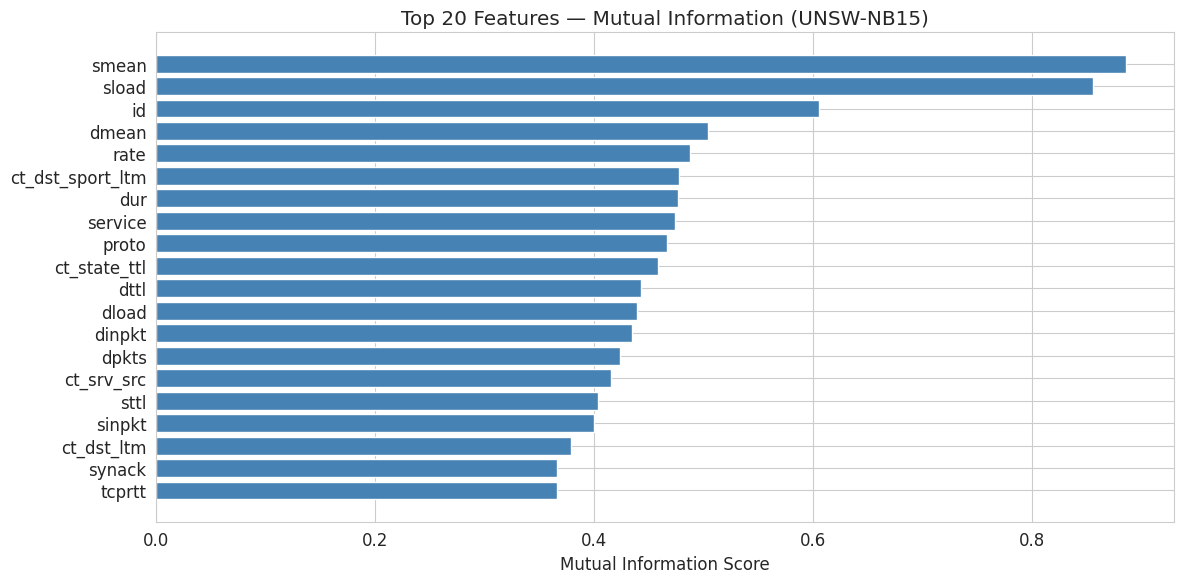

In [27]:
print('Computing Mutual Information scores on training set...')
mi_scores = mutual_info_classif(X_train_enc, y_train, random_state=42)
mi_df = pd.DataFrame({'feature': X_train_enc.columns, 'mi_score': mi_scores})
mi_df.sort_values('mi_score', ascending=False, inplace=True)

print('Top 20 features:')
print(mi_df.head(20).to_string(index=False))

top20 = mi_df.head(20)
plt.figure(figsize=(12, 6))
plt.barh(top20['feature'][::-1], top20['mi_score'][::-1], color='steelblue')
plt.xlabel('Mutual Information Score')
plt.title('Top 20 Features — Mutual Information (UNSW-NB15)')
plt.tight_layout()
plt.savefig('mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
TOP_K = 30
selected_features = mi_df.head(TOP_K)['feature'].tolist()

X_train_sel = X_train_enc[selected_features].copy()
X_val_sel   = X_val_enc[selected_features].copy()
X_test_sel  = X_test_enc[selected_features].copy()

print(f'Selected top {TOP_K} features.')
print(f'  Train : {X_train_sel.shape}')
print(f'  Val   : {X_val_sel.shape}')
print(f'  Test  : {X_test_sel.shape}')

Selected top 30 features.
  Train : (180370, 30)
  Val   : (25768, 30)
  Test  : (51535, 30)


## 7. Scaling + SMOTE

In [29]:
# QuantileTransformer — fit on train only
scaler = QuantileTransformer(output_distribution='normal', random_state=42)
X_train_scaled = scaler.fit_transform(X_train_sel)
X_val_scaled   = scaler.transform(X_val_sel)
X_test_scaled  = scaler.transform(X_test_sel)
print('Scaling done (QuantileTransformer).')

# SMOTE on training set only (k=3 for minority classes)
print(f'Before SMOTE: {np.bincount(y_train)}')
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print(f'After  SMOTE: {np.bincount(y_train_res)}')
print(f'Resampled training size: {X_train_res.shape[0]:,}')

Scaling done (QuantileTransformer).
Before SMOTE: [ 1874  1630 11447 31167 16972 41210 65100  9790  1058   122]
After  SMOTE: [65100 65100 65100 65100 65100 65100 65100 65100 65100 65100]
Resampled training size: 651,000


## 8. Focal Loss (Custom Objective for XGBoost Multiclass)

In [34]:
GAMMA = 2.0
ALPHA = 0.25

def focal_loss_multiclass(y_pred, dtrain):
    y_true    = dtrain.get_label().astype(int)
    n_samples = len(y_true)

    # In XGBoost 3+, y_pred is already (n_samples, n_classes)
    if y_pred.ndim == 1:
        n_cls = y_pred.shape[0] // n_samples
        y_pred_mat = y_pred.reshape(n_samples, n_cls, order='F')
    else:
        n_cls = y_pred.shape[1]
        y_pred_mat = y_pred.copy()

    y_pred_mat = y_pred_mat - y_pred_mat.max(axis=1, keepdims=True)
    exp_pred   = np.exp(y_pred_mat)
    prob       = exp_pred / exp_pred.sum(axis=1, keepdims=True)

    onehot = np.zeros_like(prob)
    onehot[np.arange(n_samples), y_true] = 1.0

    pt           = prob[np.arange(n_samples), y_true].reshape(-1, 1)
    focal_weight = (1.0 - pt) ** GAMMA

    grad = ALPHA * focal_weight * (prob - onehot)
    hess = ALPHA * focal_weight * prob * (1.0 - prob)
    hess = np.maximum(hess, 1e-6)

    # XGBoost expects 1D arrays for grad and hess or matching shape
    if y_pred.ndim == 1:
        grad = grad.reshape(n_samples * n_cls, order='F')
        hess = hess.reshape(n_samples * n_cls, order='F')

    return grad, hess


def focal_loss_eval(y_pred, dtrain):
    y_true    = dtrain.get_label().astype(int)
    n_samples = len(y_true)

    if y_pred.ndim == 1:
        n_cls = y_pred.shape[0] // n_samples
        y_pred_mat = y_pred.reshape(n_samples, n_cls, order='F')
    else:
        n_cls = y_pred.shape[1]
        y_pred_mat = y_pred.copy()

    y_pred_mat = y_pred_mat - y_pred_mat.max(axis=1, keepdims=True)
    exp_pred   = np.exp(y_pred_mat)
    prob       = exp_pred / exp_pred.sum(axis=1, keepdims=True)

    pt   = prob[np.arange(n_samples), y_true]
    pt   = np.clip(pt, 1e-7, 1.0)
    loss = -ALPHA * ((1.0 - pt) ** GAMMA) * np.log(pt)

    return 'focal_loss', float(loss.mean())


print(f'Focal Loss defined — gamma={GAMMA}, alpha={ALPHA}')


Focal Loss defined — gamma=2.0, alpha=0.25


## 9. XGBoost Training (GPU — device='cuda')

In [35]:
dtrain = xgb.DMatrix(X_train_res, label=y_train_res)
dval   = xgb.DMatrix(X_val_scaled,  label=y_val)
dtest  = xgb.DMatrix(X_test_scaled, label=y_test)

print(f'DMatrix created.')
print(f'  Train : {dtrain.num_row():,} rows x {dtrain.num_col()} cols')
print(f'  Val   : {dval.num_row():,} rows x {dval.num_col()} cols')
print(f'  Test  : {dtest.num_row():,} rows x {dtest.num_col()} cols')

DMatrix created.
  Train : 651,000 rows x 30 cols
  Val   : 25,768 rows x 30 cols
  Test  : 51,535 rows x 30 cols


In [36]:
base_params = {
    'device'           : 'cuda',
    'tree_method'      : 'hist',
    'num_class'        : n_classes,
    'max_depth'        : 6,
    'learning_rate'    : 0.1,
    'n_estimators'     : 300,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'min_child_weight' : 3,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'seed'             : 42,
    'verbosity'        : 1,
}

evals_result = {}
print('Training XGBoost with Focal Loss ')
t0 = time.time()

booster = xgb.train(
    params                = base_params,
    dtrain                = dtrain,
    num_boost_round       = base_params['n_estimators'],
    obj                   = focal_loss_multiclass,
    custom_metric         = focal_loss_eval,
    evals                 = [(dtrain, 'train'), (dval, 'val')],
    evals_result          = evals_result,
    early_stopping_rounds = 30,
    verbose_eval          = 50
)

train_time = time.time() - t0
print(f'Training time  : {train_time:.1f}s')
print(f'Best iteration : {booster.best_iteration}')

Training XGBoost with Focal Loss 
[0]	train-mlogloss:1.85062	train-focal_loss:0.33082	val-mlogloss:1.73342	val-focal_loss:0.29702
[50]	train-mlogloss:0.63782	train-focal_loss:0.07247	val-mlogloss:0.49496	val-focal_loss:0.06234
[100]	train-mlogloss:0.56673	train-focal_loss:0.06100	val-mlogloss:0.45567	val-focal_loss:0.05686
[150]	train-mlogloss:0.52888	train-focal_loss:0.05509	val-mlogloss:0.43948	val-focal_loss:0.05522
[200]	train-mlogloss:0.50366	train-focal_loss:0.05127	val-mlogloss:0.43083	val-focal_loss:0.05467
[250]	train-mlogloss:0.48437	train-focal_loss:0.04837	val-mlogloss:0.42562	val-focal_loss:0.05459
[275]	train-mlogloss:0.47655	train-focal_loss:0.04720	val-mlogloss:0.42404	val-focal_loss:0.05468
Training time  : 93.9s
Best iteration : 245


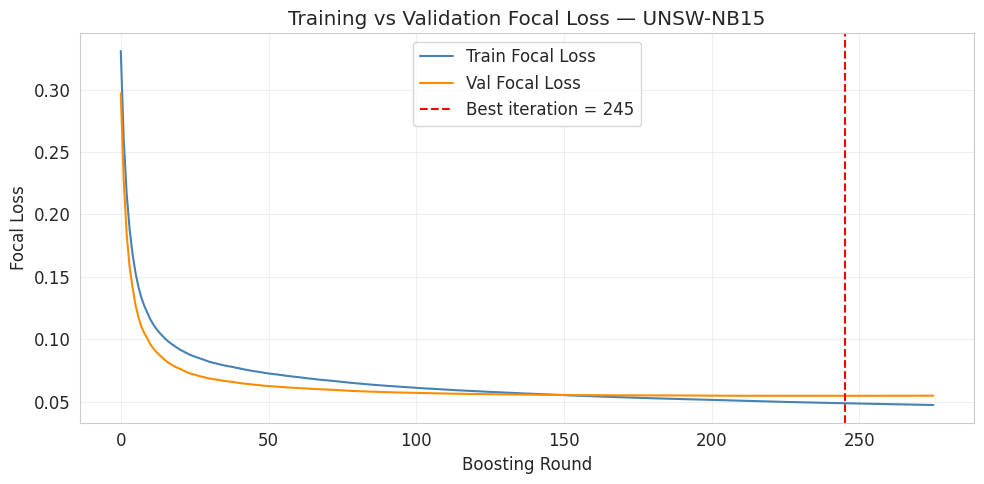

In [37]:
# Training vs Validation Focal Loss curve
train_loss = evals_result['train']['focal_loss']
val_loss   = evals_result['val']['focal_loss']

plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Train Focal Loss', color='steelblue')
plt.plot(val_loss,   label='Val Focal Loss',   color='darkorange')
plt.axvline(x=booster.best_iteration, color='red', linestyle='--',
            label=f'Best iteration = {booster.best_iteration}')
plt.xlabel('Boosting Round')
plt.ylabel('Focal Loss')
plt.title('Training vs Validation Focal Loss — UNSW-NB15')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('focal_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Hyperparameter Tuning (RandomizedSearchCV)

In [39]:
xgb_param_dist = {
    'n_estimators'     : randint(200, 600),
    'max_depth'        : randint(3, 12),
    'learning_rate'    : uniform(0.01, 0.2),
    'subsample'        : uniform(0.6, 0.4),
    'colsample_bytree' : uniform(0.6, 0.4),
    'min_child_weight' : randint(1, 10),
    'gamma'            : uniform(0, 0.5),
    'reg_alpha'        : uniform(0, 1.0),
    'reg_lambda'       : uniform(0.5, 2.0),
}

xgb_sklearn = xgb.XGBClassifier(
    device                = 'cuda',
    tree_method           = 'hist',
    objective             = 'multi:softprob',
    num_class             = n_classes,
    eval_metric           = 'mlogloss',
    random_state          = 42,
    verbosity             = 0,
    early_stopping_rounds = 20
)

print('Running RandomizedSearchCV (30 iterations)...')
t0 = time.time()

xgb_search = RandomizedSearchCV(
    xgb_sklearn,
    param_distributions = xgb_param_dist,
    n_iter       = 30,
    scoring      = 'f1_weighted',
    cv           = 3,
    verbose      = 1,
    random_state = 42,
    n_jobs       = 1
)
xgb_search.fit(
    X_train_res, y_train_res,
    eval_set = [(X_val_scaled, y_val)],
    verbose  = False
)
search_time = time.time() - t0

best_xgb = xgb_search.best_estimator_
print(f'Search time        : {search_time:.1f}s')
print(f'Best CV F1-weighted: {xgb_search.best_score_:.4f}')
print(f'Best params        : {xgb_search.best_params_}')

Running RandomizedSearchCV (30 iterations)...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Search time        : 968.7s
Best CV F1-weighted: 0.8722
Best params        : {'colsample_bytree': np.float64(0.8903822715480958), 'gamma': np.float64(0.44855512997628855), 'learning_rate': np.float64(0.18741728485302347), 'max_depth': 10, 'min_child_weight': 1, 'n_estimators': 315, 'reg_alpha': np.float64(0.08413996499504883), 'reg_lambda': np.float64(0.8232574281892275), 'subsample': np.float64(0.9594216754108317)}


In [40]:
# Re-train best model with focal loss
best_params = xgb_search.best_params_.copy()
best_params.update({
    'device'      : 'cuda',
    'tree_method' : 'hist',
    'num_class'   : n_classes,
    'seed'        : 42,
    'verbosity'   : 0,
})
n_rounds = best_params.pop('n_estimators', 300)

print(f'Re-training with best params + focal loss ({n_rounds} rounds)...')
t0 = time.time()

evals_result_best = {}
best_booster = xgb.train(
    params                = best_params,
    dtrain                = dtrain,
    num_boost_round       = n_rounds,
    obj                   = focal_loss_multiclass,
    custom_metric         = focal_loss_eval,
    evals                 = [(dtrain, 'train'), (dval, 'val')],
    evals_result          = evals_result_best,
    early_stopping_rounds = 30,
    verbose_eval          = False
)
retrain_time = time.time() - t0
print(f'Done. Best iteration: {best_booster.best_iteration} | Time: {retrain_time:.1f}s')

Re-training with best params + focal loss (315 rounds)...
Done. Best iteration: 61 | Time: 30.9s


In [42]:
# Predict on test set
raw_pred = best_booster.predict(dtest)
y_pred   = raw_pred.astype(int)
# y_prob is omitted here as predict returned classes directly

raw_pred_val = best_booster.predict(dval)
y_pred_val   = raw_pred_val.astype(int)

print(f'Test Accuracy    : {accuracy_score(y_test, y_pred):.4f}')
print(f'Test F1-weighted : {f1_score(y_test, y_pred, average="weighted"):.4f}')
print(f'Test F1-macro    : {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'Val  F1-weighted : {f1_score(y_val,  y_pred_val, average="weighted"):.4f}')

Test Accuracy    : 0.8416
Test F1-weighted : 0.8496
Test F1-macro    : 0.6140
Val  F1-weighted : 0.8515


## 11. Evaluation - Confusion Matrix, FPR per Class

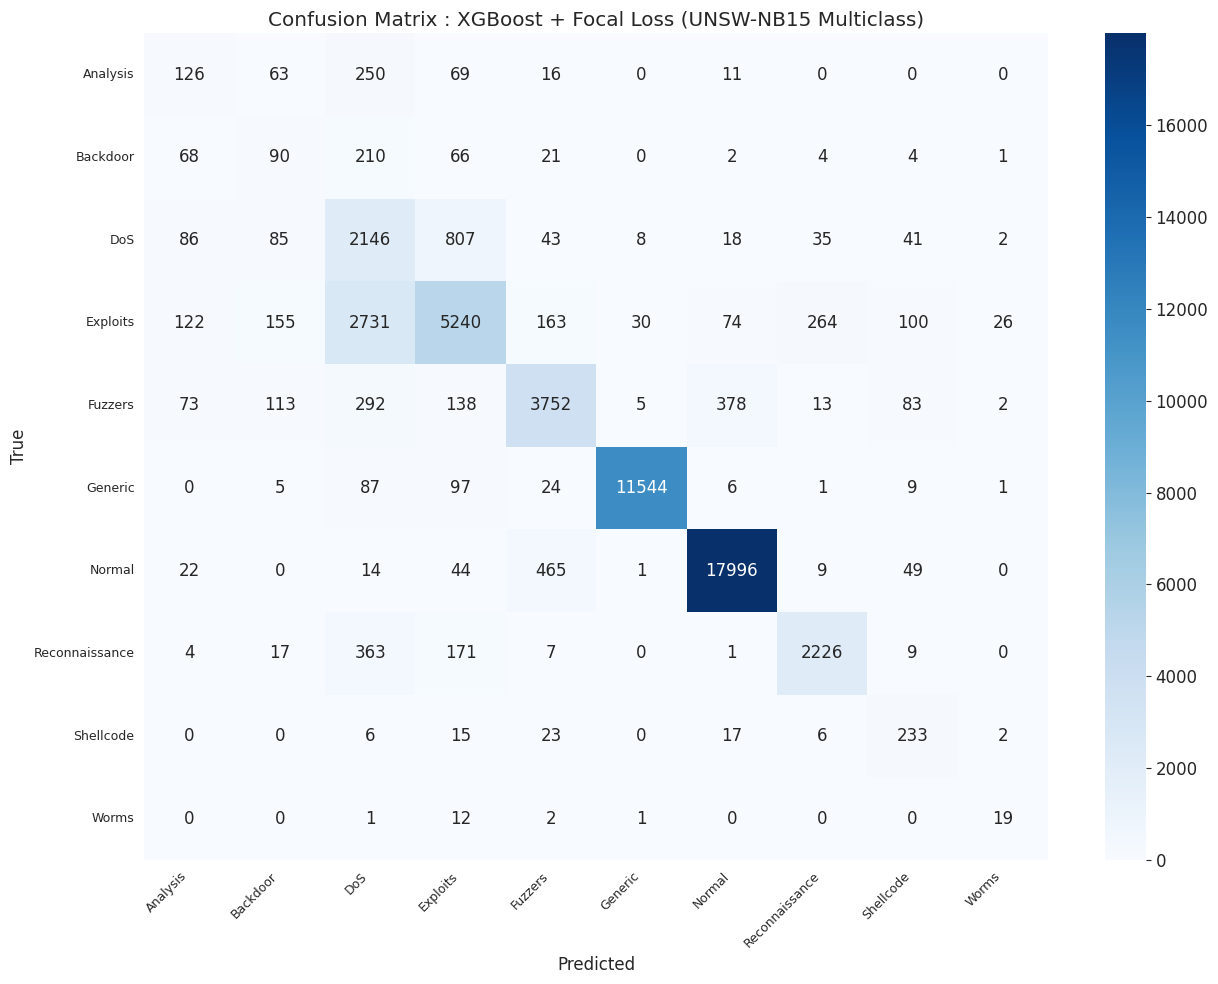

In [52]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(13, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix : XGBoost + Focal Loss (UNSW-NB15 Multiclass)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

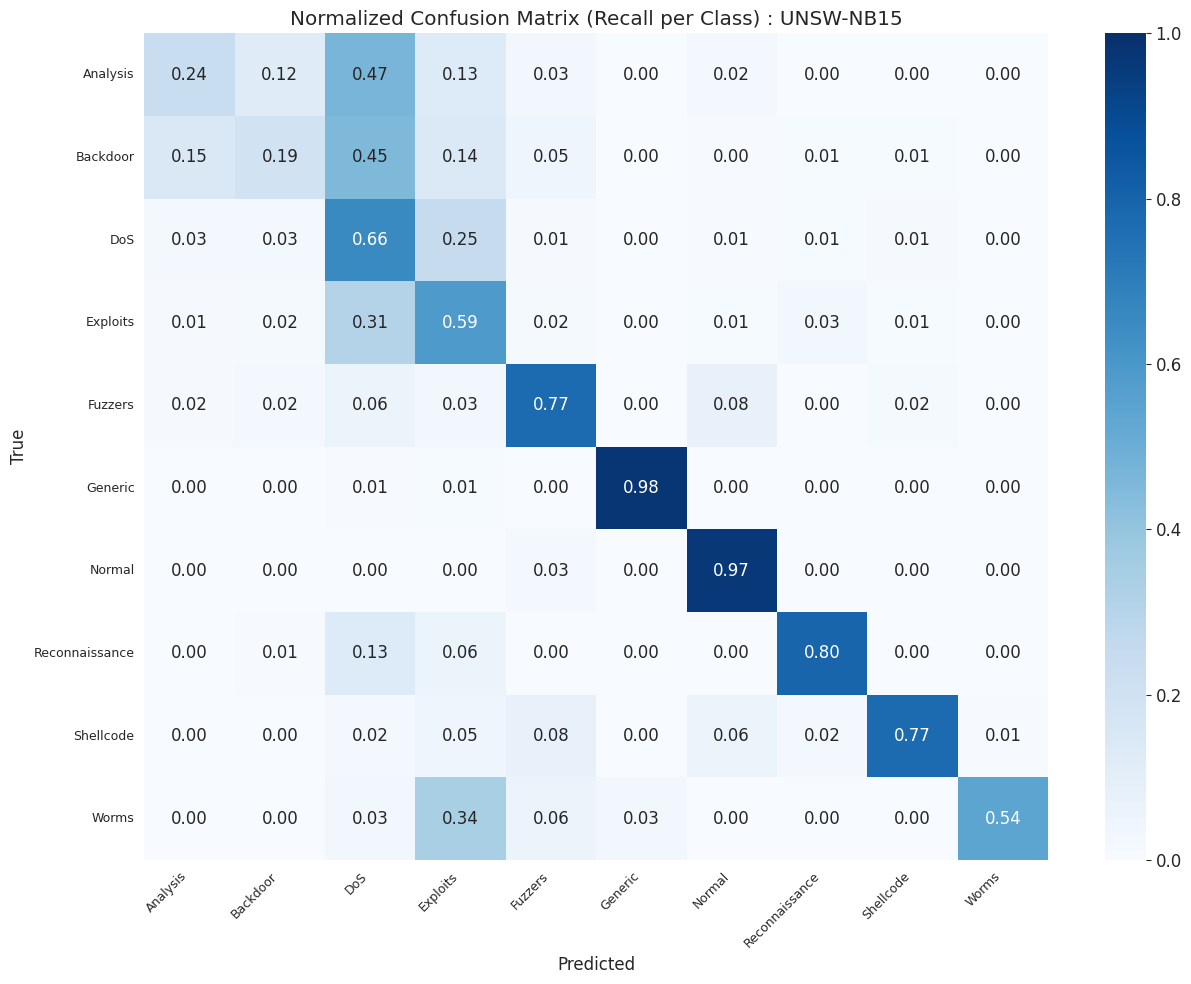

In [51]:
# Normalized Confusion Matrix
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(13, 10))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            vmin=0, vmax=1)
plt.title('Normalized Confusion Matrix (Recall per Class) : UNSW-NB15')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('confusion_matrix_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
# Per-class metrics: TP, FP, FN, TN, TPR, FPR, Precision, F1
per_class_stats = []
for i, cls in enumerate(class_names):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - TP - FN - FP

    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    PRE = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    F1  = 2 * PRE * TPR / (PRE + TPR) if (PRE + TPR) > 0 else 0.0

    per_class_stats.append({
        'Class'    : cls,
        'TP'       : int(TP),
        'FP'       : int(FP),
        'FN'       : int(FN),
        'TN'       : int(TN),
        'TPR (DR)' : round(TPR, 4),
        'FPR'      : round(FPR, 4),
        'Precision': round(PRE, 4),
        'F1 Score' : round(F1,  4),
    })

stats_df = pd.DataFrame(per_class_stats)
print('Per-Class Metrics:')
print(stats_df.to_string(index=False))
stats_df.to_csv('per_class_metrics.csv', index=False)
print('Saved: per_class_metrics.csv')

Per-Class Metrics:
         Class    TP   FP   FN    TN  TPR (DR)    FPR  Precision  F1 Score
      Analysis   126  375  409 50625    0.2355 0.0074     0.2515    0.2432
      Backdoor    90  438  376 50631    0.1931 0.0086     0.1705    0.1811
           DoS  2146 3954 1125 44310    0.6561 0.0819     0.3518    0.4580
      Exploits  5240 1419 3665 41211    0.5884 0.0333     0.7869    0.6733
       Fuzzers  3752  764 1097 45922    0.7738 0.0164     0.8308    0.8013
       Generic 11544   45  230 39716    0.9805 0.0011     0.9961    0.9882
        Normal 17996  507  604 32428    0.9675 0.0154     0.9726    0.9701
Reconnaissance  2226  332  572 48405    0.7956 0.0068     0.8702    0.8312
     Shellcode   233  295   69 50938    0.7715 0.0058     0.4413    0.5614
         Worms    19   34   16 51466    0.5429 0.0007     0.3585    0.4318
Saved: per_class_metrics.csv


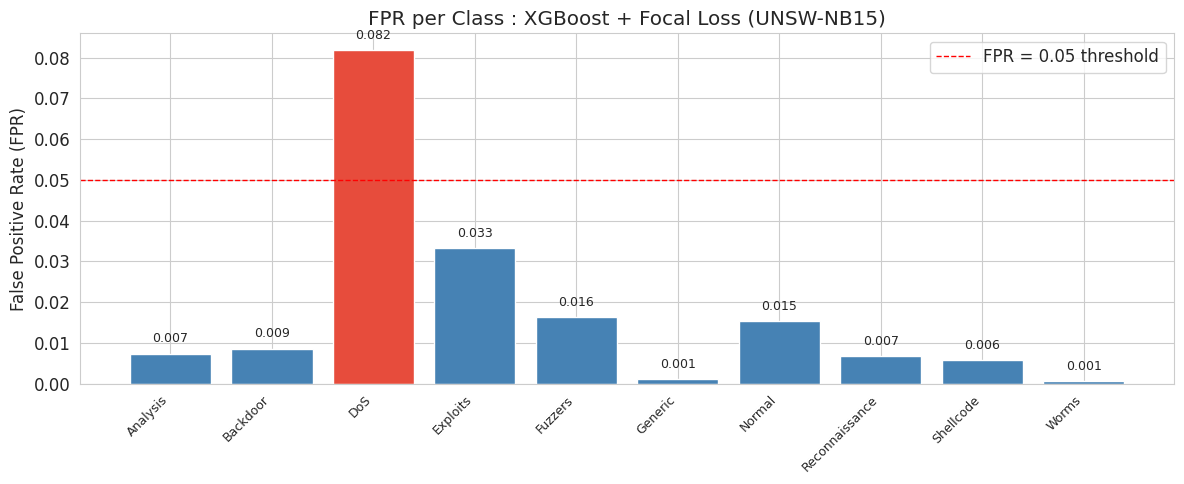

In [50]:
# FPR per class
plt.figure(figsize=(12, 5))
colors = ['#e74c3c' if v > 0.05 else 'steelblue' for v in stats_df['FPR']]
bars = plt.bar(stats_df['Class'], stats_df['FPR'], color=colors)
plt.axhline(y=0.05, color='red', linestyle='--', linewidth=1, label='FPR = 0.05 threshold')
for bar, v in zip(bars, stats_df['FPR']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('False Positive Rate (FPR)')
plt.title('FPR per Class : XGBoost + Focal Loss (UNSW-NB15)')
plt.legend()
plt.tight_layout()
plt.savefig('fpr_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

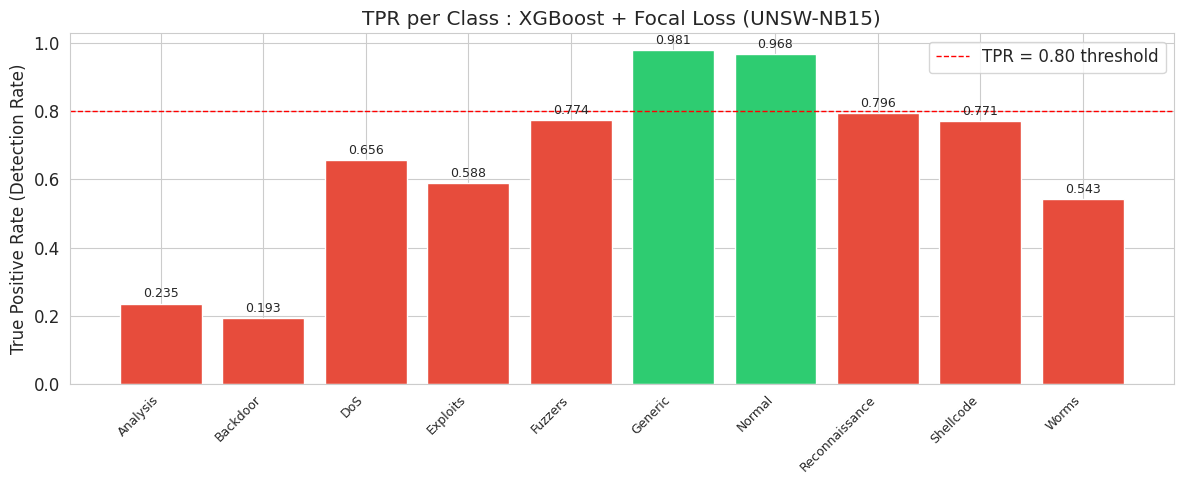

In [49]:
# TPR (Detection Rate) per class
plt.figure(figsize=(12, 5))
colors_tpr = ['#e74c3c' if v < 0.80 else '#2ecc71' for v in stats_df['TPR (DR)']]
bars = plt.bar(stats_df['Class'], stats_df['TPR (DR)'], color=colors_tpr)
plt.axhline(y=0.80, color='red', linestyle='--', linewidth=1, label='TPR = 0.80 threshold')
for bar, v in zip(bars, stats_df['TPR (DR)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('True Positive Rate (Detection Rate)')
plt.title('TPR per Class : XGBoost + Focal Loss (UNSW-NB15)')
plt.legend()
plt.tight_layout()
plt.savefig('tpr_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

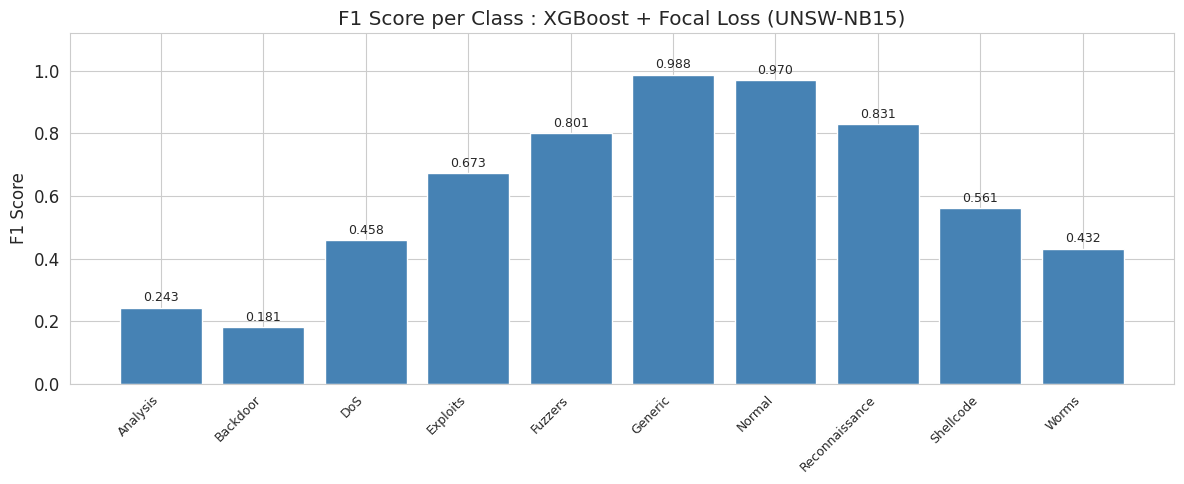

In [53]:
# F1 Score per class
plt.figure(figsize=(12, 5))
plt.bar(stats_df['Class'], stats_df['F1 Score'], color='steelblue')
for i, (cls, v) in enumerate(zip(stats_df['Class'], stats_df['F1 Score'])):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylim(0, 1.12)
plt.ylabel('F1 Score')
plt.title('F1 Score per Class : XGBoost + Focal Loss (UNSW-NB15)')
plt.tight_layout()
plt.savefig('f1_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Feature Importance

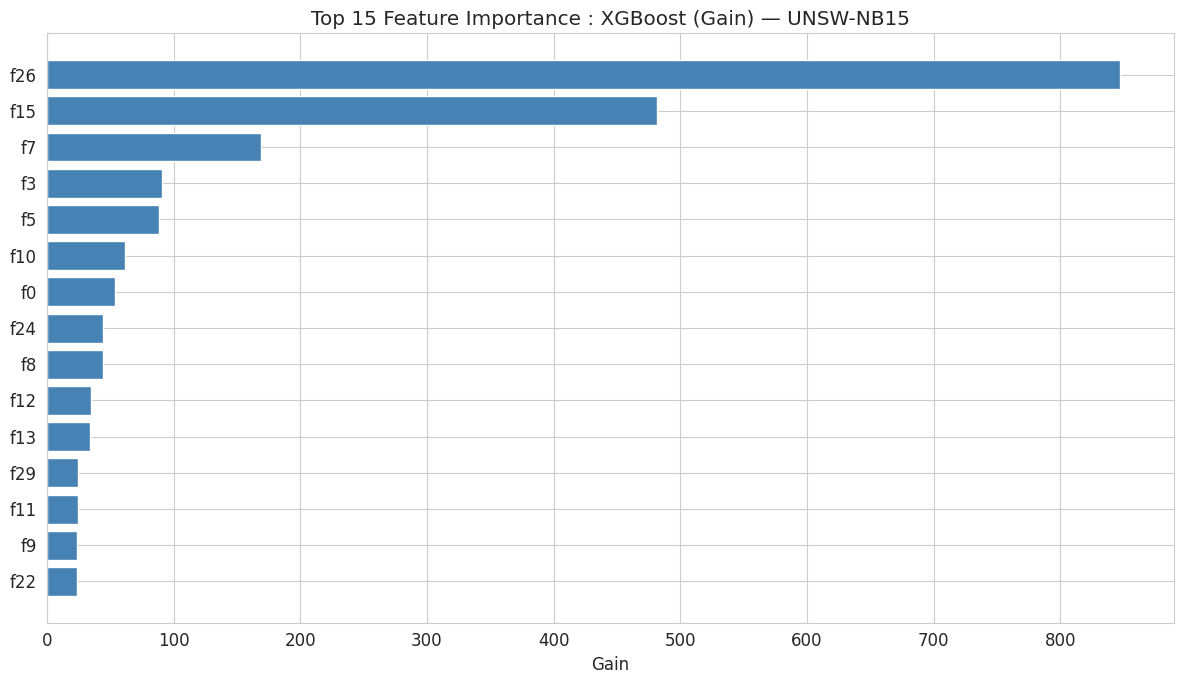

Top 15 features by gain:
feature  importance
    f26  847.224121
    f15  481.253662
     f7  168.844437
     f3   91.183372
     f5   88.563171
    f10   62.056778
     f0   53.448383
    f24   44.609871
     f8   44.199085
    f12   35.037708
    f13   34.244492
    f29   24.680019
    f11   24.646036
     f9   23.732563
    f22   23.680182


In [55]:
importance_dict = best_booster.get_score(importance_type='gain')
imp_df = pd.DataFrame(list(importance_dict.items()), columns=['feature', 'importance'])
imp_df.sort_values('importance', ascending=False, inplace=True)

top15 = imp_df.head(15)
plt.figure(figsize=(12, 7))
plt.barh(top15['feature'][::-1], top15['importance'][::-1], color='steelblue')
plt.xlabel('Gain')
plt.title('Top 15 Feature Importance : XGBoost (Gain) — UNSW-NB15')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 15 features by gain:')
print(top15.to_string(index=False))

## 13. Results Summary

In [58]:
print('=' * 65)
print('FINAL RESULTS SUMMARY')
print(f'Dataset    : UNSW-NB15 | Multiclass ({n_classes} classes)')
print(f'Split      : 70% train / 10% validation / 20% test')
print(f'Encoding   : Target Encoding (TargetEncoder, leak-free)')
print(f'Features   : Top-{TOP_K} by Mutual Information')
print(f'Sampling   : SMOTE (k=3) | Scaling: QuantileTransformer')
print(f'Loss       : Focal Loss (gamma={GAMMA}, alpha={ALPHA})')
print(f'Model      : XGBoost')
print(f'Best iter  : {best_booster.best_iteration}')
print('=' * 65)
print(f'{"Metric":<25} {"Value":>18}')
print('-' * 45)
print(f'{"Accuracy":<25} {accuracy_score(y_test, y_pred):>18.4f}')
print(f'{"F1-Weighted":<25} {f1_score(y_test, y_pred, average="weighted"):>18.4f}')
print(f'{"F1-Macro":<25} {f1_score(y_test, y_pred, average="macro"):>18.4f}')
print(f'{"Precision-W":<25} {precision_score(y_test, y_pred, average="weighted"):>18.4f}')
print(f'{"Recall-W":<25} {recall_score(y_test, y_pred, average="weighted"):>18.4f}')
print(f'{"Training Time (s)":<25} {train_time:>18.1f}')
print('=' * 65)

print('\nPer-Class Summary:')
print(stats_df[['Class', 'TPR (DR)', 'FPR', 'Precision', 'F1 Score']].to_string(index=False))

print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

FINAL RESULTS SUMMARY
Dataset    : UNSW-NB15 | Multiclass (10 classes)
Split      : 70% train / 10% validation / 20% test
Encoding   : Target Encoding (TargetEncoder, leak-free)
Features   : Top-30 by Mutual Information
Sampling   : SMOTE (k=3) | Scaling: QuantileTransformer
Loss       : Focal Loss (gamma=2.0, alpha=0.25)
Model      : XGBoost
Best iter  : 61
Metric                                 Value
---------------------------------------------
Accuracy                              0.8416
F1-Weighted                           0.8496
F1-Macro                              0.6140
Precision-W                           0.8693
Recall-W                              0.8416
Training Time (s)                       93.9

Per-Class Summary:
         Class  TPR (DR)    FPR  Precision  F1 Score
      Analysis    0.2355 0.0074     0.2515    0.2432
      Backdoor    0.1931 0.0086     0.1705    0.1811
           DoS    0.6561 0.0819     0.3518    0.4580
      Exploits    0.5884 0.0333     0.7869    